## SDM274 Assignment 06 - K-Nearest Neighbor (KNN) Algorithm

**Requirements**

Breast Cancer Wisconsin (Original) Data Set Analysis Using KNN Algorithm

**Objective**: In this assignment, you are required to perform the following tasks using the Breast Cancer Wisconsin (Original) data set, which is available under the filename wdbc.data. More information regarding the data set can be found in wdbc.names.

1. **Data Splitting**: Divide the dataset into a training set and a testing set with a ratio of 70% for training and 30% for testing.

2. **KNN Algorithm Implementation**: Write a code for the K-Nearest Neighbors (KNN) algorithm.

3. **Testing and Analysis**: Test the algorithm with varying values of k from 1 to 10 using the testing set, and provide the accuracy for each k. Analyze how the accuracy changes with different values of k.

Use the following packages mainly:
- Numpy for matrix operations and data manipulation.
- Pandas for data manipulation.
- Matplotlib for data visualization.
- Scipy for KD Tree implementation.

In [284]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

%matplotlib inline

First a KNN class is written with a KD-Tree stored for maintaining nearest neighbour data. Train the model with the training data and then allow single point prediction and batch prediction.

In [285]:
class KNN:
    def __init__(self, k):
        self.k = k
        self.kdtree = None
    
    def train(self, X, y):
        self.X = X
        self.y = y
        self.kdtree = KDTree(X)
    
    def predict_single(self, x):
        _, idx = self.kdtree.query(x, k = self.k, p = 2)
        if not isinstance(idx, np.ndarray):
            idx = [idx]
        return np.argmax(np.bincount(self.y[idx]))
    
    def predict(self, X):
        return np.array([self.predict_single(x) for x in X])

Then, the dataset is divided into a training set and a test set:

In [286]:
def random_split(X, y, test_size = 0.3, seed = None):
    if seed is not None:
        np.random.seed(seed)

    indices = np.arange(len(X))
    np.random.shuffle(indices)

    split_index = int(len(X) * (1 - test_size))
    train_indices, test_indices = indices[:split_index], indices[split_index:]

    X_train, y_train = X[train_indices], y[train_indices]
    X_test, y_test = X[test_indices], y[test_indices]

    return X_train, y_train, X_test, y_test

Use pandas to read the data from the wdbc.data file, rounding off the first column (ID) and then converting the second column (diagnosis) to 0 and 1, where 1 indicates malignant (M) and 0 indicates benign (B).

In [287]:
# load data (M = malignant -> 1, B = benign -> 0)
wdbc_csv = pd.read_csv('wdbc.data', header = None)
t_train = (wdbc_csv[1].values == 'M').astype(int)
X_train = wdbc_csv.drop([0, 1], axis = 1).values

# split the data
X_train, t_train, X_test, y_test = random_split(X_train, t_train, test_size = 0.3) # , seed = 42)
print(X_train.shape, t_train.shape, X_test.shape, y_test.shape)

(398, 30) (398,) (171, 30) (171,)


Then traverse the values of k from 1 to 50 and try the accuracy of the KNN algorithm for different values of k on the training and test sets respectively.

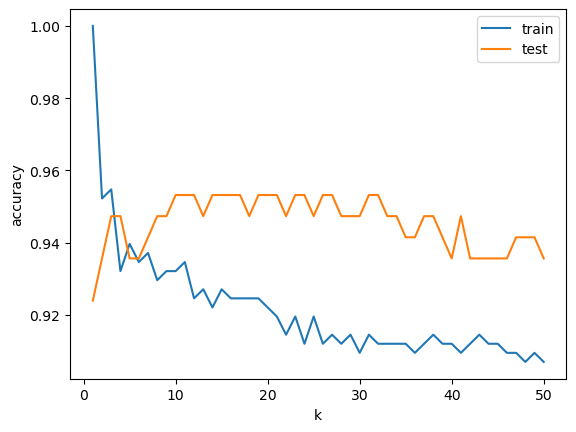

In [288]:
def eval_accuracy(y, t):
    return np.sum(y == t) / len(t)

train_acc_list = []
test_acc_list = []

k_range = np.arange(1, 51)

for k in k_range:
    knn = KNN(k)
    knn.train(X_train, t_train)

    y_pred_train = knn.predict(X_train)
    acc_train = eval_accuracy(y_pred_train, t_train)
    train_acc_list.append(acc_train)

    y_pred_test = knn.predict(X_test)
    acc_test = eval_accuracy(y_pred_test, y_test)
    test_acc_list.append(acc_test)

plt.plot(k_range, train_acc_list, label = 'train')
plt.plot(k_range, test_acc_list, label = 'test')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.legend()
plt.show()

The results are plotted as a graph as shown above, where the x-axis is the k-value and the y-axis is the accuracy rate; the blue line is the accuracy rate on the training set and the orange line is the accuracy rate on the test set.

It can be observed that the accuracy rate on the training set has an overall increasing trend as the k value decreases, while the accuracy rate on the test set first increases and then decreases as the k value decreases, and roughly reaches its maximum value when k is around 20.

A simple analysis can conclude the reason: the k value of the KNN algorithm represents the flexibility of the model, the smaller k is the more flexible the model is and the more it can adapt to the training set. When k is 1, the prediction only refers to the nearest point, i.e., the training set data itself, so it can achieve 100% accuracy. The performance on the test set is best when k is moderate; when k is too low, the model is overfitted and the test performance decreases; when k is too high, the prediction result is too smooth, the model is underfitted, and the test performance also decreases.